# Exploratory Data Analysis (EDA) of Nobel Prize Winners: Patterns Across Time and Categories

<p><img style="display: block; margin-right: auto; max-width: 250px;" src="images/Nobel_Prize.png" alt="Nobel Prize medal"></p>

## 1. Introduction: Exploring the Legacy of the Nobel Prize

The Nobel Prize is one of the most prestigious global awards, recognizing exceptional contributions in physics, chemistry, medicine, literature, economics, and peace since 1901. While it represents the highest level of achievement, it also raises interesting questions about representation and fairness over time.

This project explores the history of Nobel Prize winners using data analysis and visualisation techniques. The objective is to identify patterns in how prizes have been awarded across different dimensions such as year, category, country, gender, and affiliation.

Using Python-based tools for data manipulation and exploratory data analysis (EDA), this project aims to:

- Analyze trends in Nobel Prize awards over time
- Examine distribution across categories and regions
- Identify potential biases or disparities in award allocation
- Present insights through clear and intuitive visualisations

The analysis provides a data-driven perspective on whether the Nobel Prize distribution reflects global diversity—or if certain groups and regions have been historically overrepresented.

In [2]:
# Loading in required libraries
import pandas as pd
import seaborn as sns
import numpy as np

# Reading in the Nobel Prize data
nobel = pd.read_csv("datasets/nobel.csv")

# Taking a look at the first several winners
nobel.head(6)

,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,birth_country,sex,organization_name,organization_city,organization_country,death_date,death_city,death_country
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,160,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Male,Berlin University,Berlin,Germany,1911-03-01,Berlin,Germany
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,569,Individual,Sully Prudhomme,1839-03-16,Paris,France,Male,NaN,NaN,NaN,1907-09-07,Châtenay,France
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,293,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Male,Marburg University,Marburg,Germany,1917-03-31,Marburg,Germany
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,462,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Male,NaN,NaN,NaN,1910-10-30,Heiden,Switzerland
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,463,Individual,Frédéric Passy,1822-05-20,Paris,France,Male,NaN,NaN,NaN,1912-06-12,Paris,France
5,1901,Physics,The Nobel Prize in Physics 1901,"""in recognition of the extraordinary services ...",1/1,1,Individual,Wilhelm Conrad Röntgen,1845-03-27,Lennep (Remscheid),Prussia (Germany),Male,Munich University,Munich,Germany,1923-02-10,Munich,Germany


## 2. Breaking Down the Winners

To begin the analysis, we take an initial look at the Nobel Prize laureates. Even a quick glance at the earliest awards reveals some interesting patterns. For example, one of the first winners in 1901 was Wilhelm Conrad Röntgen, best known for discovering X-rays—highlighting the caliber of achievements recognized by the prize.

However, the early data also reveals a lack of diversity. All Nobel Prize winners in 1901 were male and based in Europe. This raises an important question: have these patterns changed over time, or do similar trends persist across the full dataset?

To answer this, we expand our analysis to include all Nobel Prize winners from 1901 to 2016. In this section, we focus on understanding the overall distribution of laureates by key attributes such as gender and nationality.

Specifically, we aim to:

- Determine the total number of Nobel Prizes awarded during this period (including shared prizes)
- Compare the number of prizes awarded to male and female laureates
- Identify the top 10 most represented nationalities among winners

This initial breakdown provides a foundation for identifying broader trends and potential imbalances, which will be explored in more detail in subsequent sections.

In [4]:
# Calculate the total number of Nobel Prizes awarded between 1901 and 2016 (including shared prizes)
display(len(nobel))

911

In [5]:
# Analyze the distribution of prizes by gender (male vs female laureates)
display(nobel["sex"].value_counts())

sex
Male      836
Female     49
Name: count, dtype: int64

In [6]:
# Identify the top 10 nationalities with the highest number of Nobel Prize winners
nobel["birth_country"].value_counts().head(10)

birth_country
United States of America    259
United Kingdom               85
Germany                      61
France                       51
Sweden                       29
Japan                        24
Netherlands                  18
Canada                       18
Russia                       17
Italy                        17
Name: count, dtype: int64

## 3. The Rise of the United States in Nobel Prizes

From the previous analysis, we observed that the most frequently represented Nobel laureates between 1901 and 2016 are men born in the United States. While this may not be surprising today, it contrasts sharply with the early years of the Nobel Prize, where winners were exclusively European.

This shift suggests a significant change in the global landscape of scientific, cultural, and political influence over time. The key question is: when did the United States begin to dominate Nobel Prize awards?

To investigate this, we analyze the proportion of Nobel laureates born in the United States across different decades. By grouping the data by decade and calculating the share of U.S.-born winners, we can track how representation has evolved over time and identify the point at which the U.S. emerged as a leading contributor.

This analysis helps highlight broader historical trends, including shifts in research leadership, global influence, and investment in innovation.

In [7]:
# Calculate the proportion of Nobel Prize winners born in the United States for each decade
nobel['usa_born_winner'] = nobel["birth_country"] == "United States of America"
nobel['decade'] = (np.floor((nobel['year']/10))*10).astype(int)
prop_usa_winners = nobel.groupby('decade', as_index=False)['usa_born_winner'].mean()

# Display the proportions of USA born winners per decade
display(prop_usa_winners)

,decade,usa_born_winner
0,1900,0.017544
1,1910,0.075000
2,1920,0.074074
3,1930,0.250000
4,1940,0.302326
5,1950,0.291667
6,1960,0.265823
7,1970,0.317308
8,1980,0.319588
9,1990,0.403846


A table is OK, but to see when the USA started to dominate the Nobel charts we need a plot!

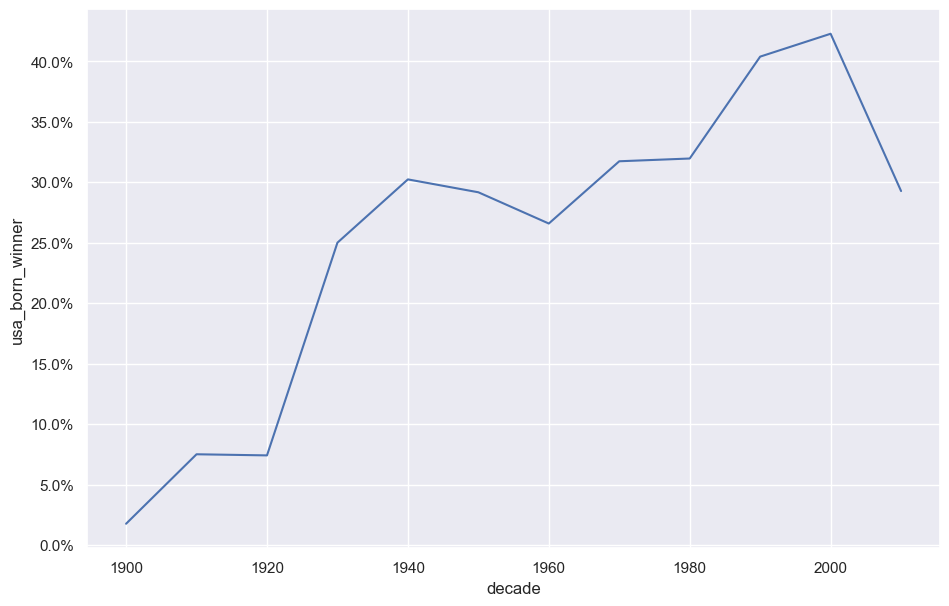

In [8]:
# Setting the plotting theme
sns.set()
# and setting the size of all plots.
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [11, 7]

# Plotting USA born winners 
ax = sns.lineplot(x='decade', y='usa_born_winner', data=prop_usa_winners)

# Adding %-formatting to the y-axis
from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

## 4. Analysing Gender Representation Across Categories

From the previous analysis, we saw that the United States emerged as a dominant contributor to Nobel Prize winners starting in the 1930s. However, another pattern is even more consistent across the entire history of the Nobel Prize: male laureates overwhelmingly outnumber female laureates.

While this imbalance may not be unexpected given historical disparities in access to education and research opportunities, it raises important questions:

- How significant is the gender gap in Nobel Prize awards?
- Has female representation improved over time?
- Does the imbalance vary across different prize categories?

To explore this, we calculate the proportion of female Nobel Prize winners over time, grouped by decade and category. This allows us to track trends in gender representation and compare how different fields have evolved.

By visualising these proportions, we can identify whether progress has been made toward greater gender balance and which disciplines have seen the most change. This analysis provides a clearer picture of how inclusivity in Nobel Prize recognition has developed over more than a century.

In [10]:
# Create a boolean column indicating whether a laureate is female
nobel['female_winner'] = nobel['sex'] == 'Female'

# Group data by decade and category, then calculate the proportion of female winners
prop_female_winners = nobel.groupby(['decade','category'], as_index=False)['female_winner'].mean()
display(prop_female_winners)

,decade,category,female_winner
0,1900,Chemistry,0.000000
1,1900,Literature,0.100000
2,1900,Medicine,0.000000
3,1900,Peace,0.071429
4,1900,Physics,0.076923
...,...,...,...
61,2010,Economics,0.000000
62,2010,Literature,0.285714
63,2010,Medicine,0.125000
64,2010,Peace,0.400000


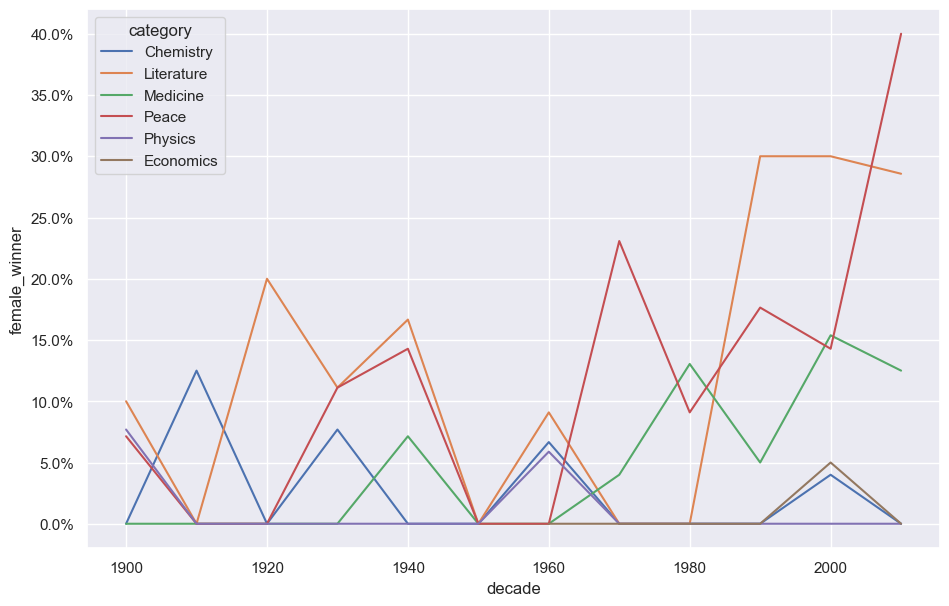

In [11]:
# Plot the proportion of female laureates over time for each Nobel Prize category
ax = sns.lineplot(x='decade', y='female_winner', hue='category', data=prop_female_winners)

# Format the y-axis to display percentages for easier interpretation
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

## 5. Breaking Barriers: The First Woman Nobel Winner

The previous analysis highlighted a significant gender imbalance in Nobel Prize awards. While there have been improvements over time in certain categories, female representation remains relatively low compared to male laureates.

This naturally leads to an important historical question: who was the first woman to receive a Nobel Prize, and in which category?

To answer this, we filter the dataset to include only female laureates and identify the earliest recorded winner. This allows us to pinpoint the moment when women first broke into what was, at the time, an entirely male-dominated recognition system.

The analysis reveals that Marie Curie was the first woman to win a Nobel Prize. She received the award in Physics in 1903, marking a groundbreaking milestone in both scientific achievement and gender representation. Her recognition not only reflected her pioneering work on radioactivity but also set a precedent for future generations of women in science and beyond.

In [12]:
# Filter the dataset to include only female Nobel laureates
nobel_female = nobel[nobel['sex']=='Female']

# Identify the earliest (first) female Nobel Prize winner based on year. Display details of the first female laureate
nobel_female.nsmallest(n=1, columns='year')

,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,...,sex,organization_name,organization_city,organization_country,death_date,death_city,death_country,usa_born_winner,decade,female_winner
19,1903,Physics,The Nobel Prize in Physics 1903,"""in recognition of the extraordinary services ...",1/4,6,Individual,"Marie Curie, née Sklodowska",1867-11-07,Warsaw,...,Female,NaN,NaN,NaN,1934-07-04,Sallanches,France,False,1900,True


## 6. Multiple Nobel Prize Winners

For many scientists, writers, and activists, winning a Nobel Prize represents the pinnacle of their career. However, a small and exceptional group of individuals have achieved this honor more than once.

This section focuses on identifying these multiple winners (those who have received two or more Nobel Prizes). By grouping the dataset by individual laureates and counting the number of prizes awarded to each, we can isolate this rare group.

Analysing repeat winners not only highlights extraordinary contributions but also provides insight into individuals whose work has had a lasting and wide-ranging impact across disciplines or over time.

In [13]:
# Group the dataset by laureate name and filter those with two or more Nobel Prizes. Display the list of repeat laureates
nobel.groupby('full_name').filter(lambda group: len(group)>=2)

,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,...,sex,organization_name,organization_city,organization_country,death_date,death_city,death_country,usa_born_winner,decade,female_winner
19,1903,Physics,The Nobel Prize in Physics 1903,"""in recognition of the extraordinary services ...",1/4,6,Individual,"Marie Curie, née Sklodowska",1867-11-07,Warsaw,...,Female,NaN,NaN,NaN,1934-07-04,Sallanches,France,False,1900,True
62,1911,Chemistry,The Nobel Prize in Chemistry 1911,"""in recognition of her services to the advance...",1/1,6,Individual,"Marie Curie, née Sklodowska",1867-11-07,Warsaw,...,Female,Sorbonne University,Paris,France,1934-07-04,Sallanches,France,False,1910,True
89,1917,Peace,The Nobel Peace Prize 1917,NaN,1/1,482,Organization,Comité international de la Croix Rouge (Intern...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1910,False
215,1944,Peace,The Nobel Peace Prize 1944,NaN,1/1,482,Organization,Comité international de la Croix Rouge (Intern...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1940,False
278,1954,Chemistry,The Nobel Prize in Chemistry 1954,"""for his research into the nature of the chemi...",1/1,217,Individual,Linus Carl Pauling,1901-02-28,"Portland, OR",...,Male,California Institute of Technology (Caltech),"Pasadena, CA",United States of America,1994-08-19,"Big Sur, CA",United States of America,True,1950,False
283,1954,Peace,The Nobel Peace Prize 1954,NaN,1/1,515,Organization,Office of the United Nations High Commissioner...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1950,False
298,1956,Physics,The Nobel Prize in Physics 1956,"""for their researches on semiconductors and th...",1/3,66,Individual,John Bardeen,1908-05-23,"Madison, WI",...,Male,University of Illinois,"Urbana, IL",United States of America,1991-01-30,"Boston, MA",United States of America,True,1950,False
306,1958,Chemistry,The Nobel Prize in Chemistry 1958,"""for his work on the structure of proteins, es...",1/1,222,Individual,Frederick Sanger,1918-08-13,Rendcombe,...,Male,University of Cambridge,Cambridge,United Kingdom,2013-11-19,Cambridge,United Kingdom,False,1950,False
340,1962,Peace,The Nobel Peace Prize 1962,NaN,1/1,217,Individual,Linus Carl Pauling,1901-02-28,"Portland, OR",...,Male,California Institute of Technology (Caltech),"Pasadena, CA",United States of America,1994-08-19,"Big Sur, CA",United States of America,True,1960,False
348,1963,Peace,The Nobel Peace Prize 1963,NaN,1/2,482,Organization,Comité international de la Croix Rouge (Intern...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1960,False


## 7. Analysing Age at the Time of Award

The list of repeat laureates includes several notable figures such as Marie Curie, John Bardeen, Frederick Sanger, and Linus Pauling—individuals whose contributions were recognised multiple times across different fields. Additionally, organisations such as the International Committee of the Red Cross and the United Nations High Commissioner for Refugees have also received the Nobel Prize more than once.

This raises another interesting question: at what age do individuals typically receive a Nobel Prize?

To explore this, we calculate the age of each laureate at the time of receiving the award by comparing their birth year with the award year. We then visualise how this age distribution has evolved over time.

The resulting plot reveals a noticeable trend: Nobel laureates tend to receive their awards later in life, and this age has gradually increased over the decades. This may reflect the growing complexity of research, longer career trajectories, and the time required for contributions to gain recognition.

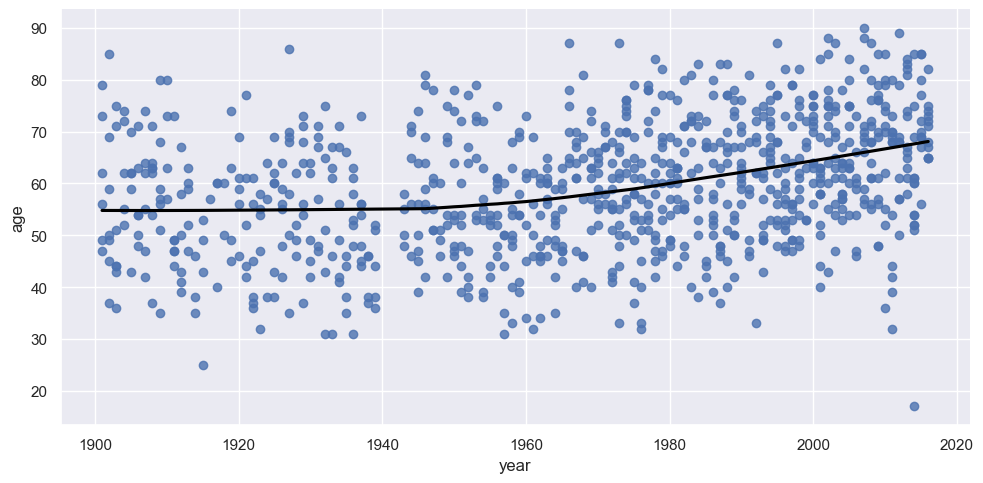

In [14]:
# Convert birth_date column to datetime format for accurate calculations
nobel['birth_date'] = pd.to_datetime(nobel['birth_date'])

# Compute the age of each laureate at the time of receiving the Nobel Prize
nobel['age'] = nobel['year'] - nobel['birth_date'].dt.year

# Plot age vs year to visualise trends over time (with smoothing)
sns.lmplot(x='year', y='age', data=nobel, lowess=True, aspect=2, line_kws={'color' : 'black'})

## 8. Age Trends Across Nobel Prize Categories

The previous analysis showed that Nobel laureates tend to receive their awards later in life, with the average age increasing over time. However, this overall trend may vary across different prize categories.

In this section, we break down the age distribution by Nobel Prize category to explore whether certain fields tend to recognise achievements earlier or later in life.

By visualising age trends separately for each category, we can observe:

- Differences in average age at the time of award across disciplines
- Variations in how age trends have evolved over time
- The spread and density of laureates within each category

The plots also highlight broader patterns in the dataset. For example, the increasing density of data points in recent decades reflects the rise in shared prizes, resulting in more laureates per year. Additionally, there is a noticeable gap in awards during the period of World War II, which impacted prize distribution across several categories.

This category-level view provides deeper insight into how recognition timing differs across fields and further enriches our understanding of Nobel Prize trends.

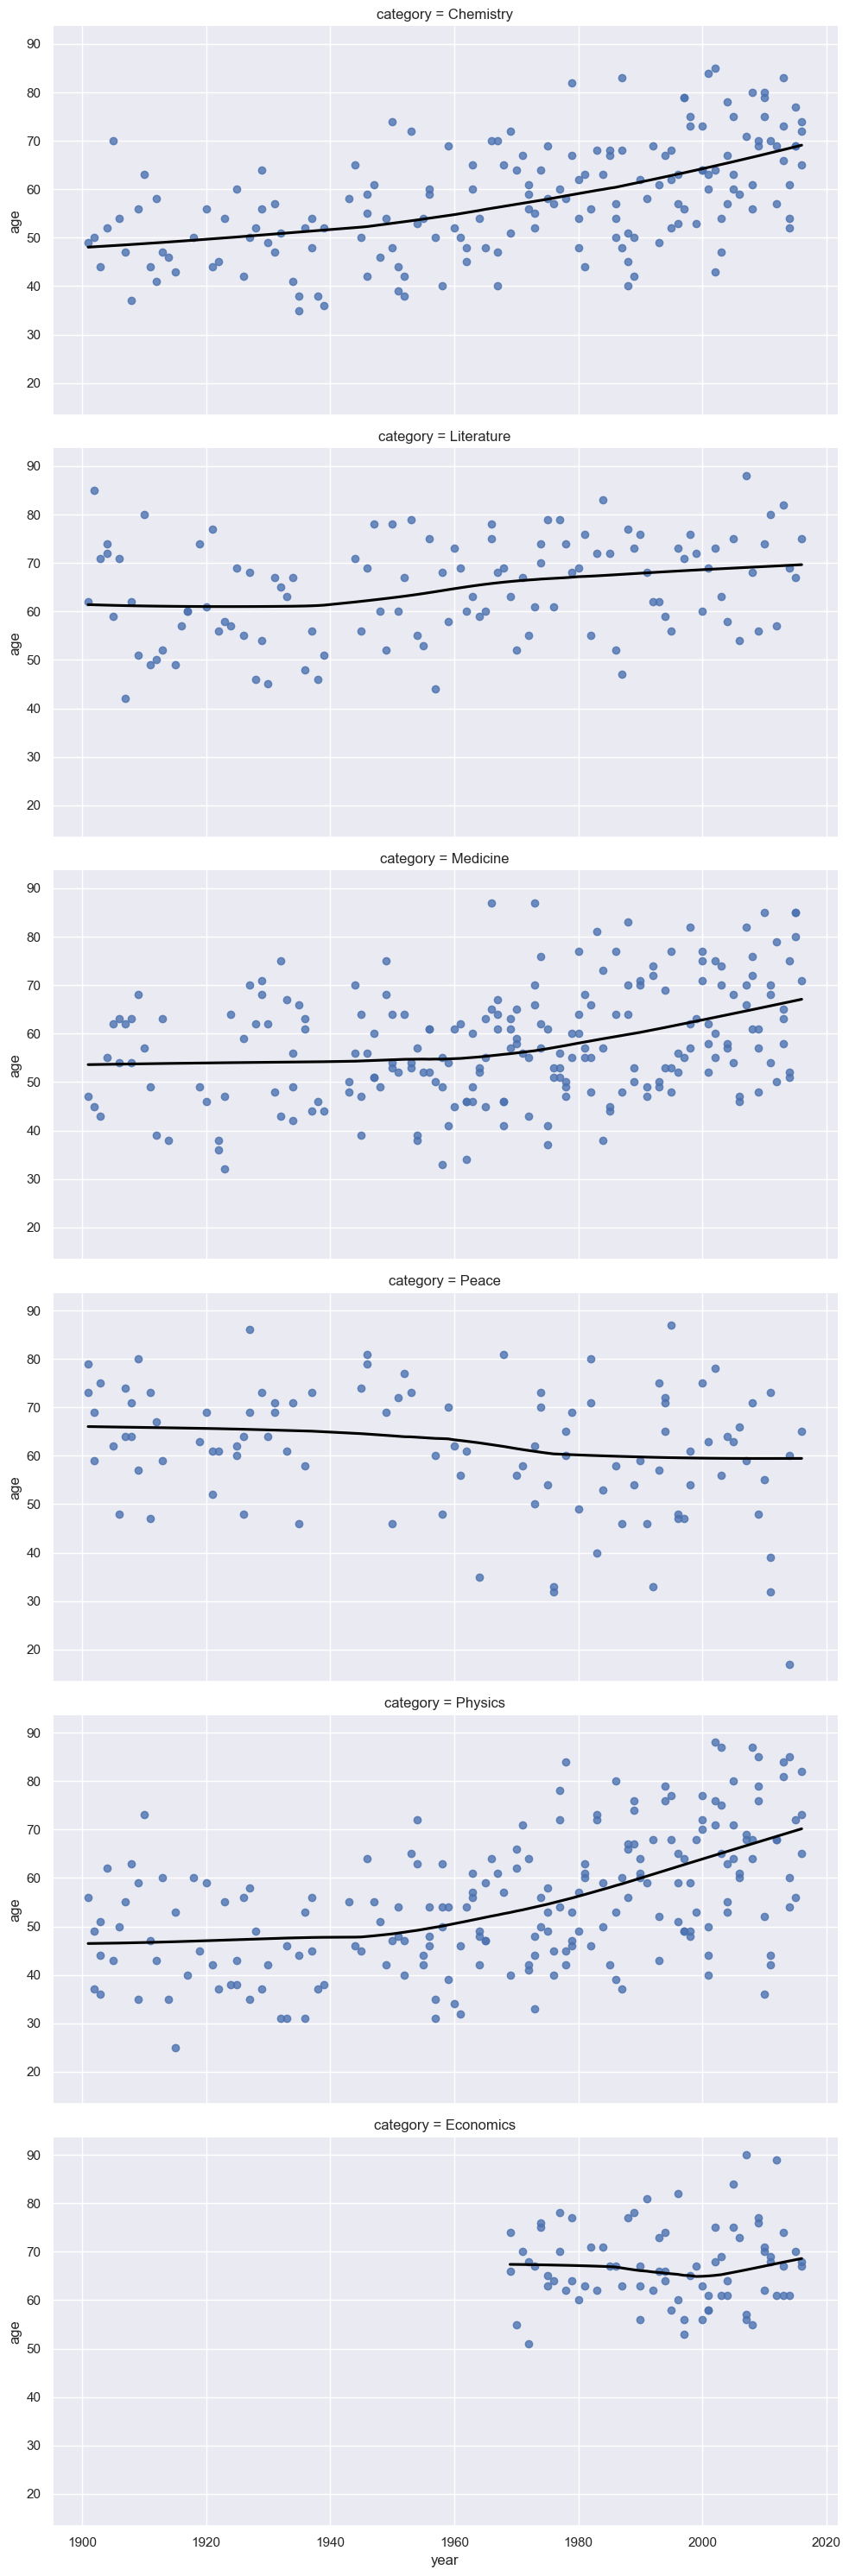

In [15]:
# Plot age vs year, separated by Nobel Prize category
sns.lmplot(x='year', y='age', row='category', data=nobel, lowess=True, aspect=2, line_kws={'color' : 'black'})

## 9. Youngest and Oldest Nobel Laureates

Building on the previous analysis, we observed that Nobel Prize winners, particularly in fields like physics, chemistry, and medicine—have tended to receive their awards at increasingly older ages over time. In contrast, categories such as literature and economics show more stable age patterns, while the peace category occasionally highlights much younger recipients.

This variation raises an interesting question: who are the youngest and oldest Nobel Prize winners in history?

To answer this, we identify the laureates with the minimum and maximum ages at the time of receiving their awards. This allows us to explore the extremes of recognition and better understand the range of ages across all Nobel Prize categories.

Examining these outliers provides additional context to the broader age trends and highlights how exceptional contributions can be recognized at very different stages of life.

In [16]:
# Identify the oldest Nobel Prize winner based on age
oldest = nobel.nlargest(1, 'age')
# Display the result
display(oldest)

,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,...,organization_name,organization_city,organization_country,death_date,death_city,death_country,usa_born_winner,decade,female_winner,age
793,2007,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for having laid the foundations of mechanism ...",1/3,820,Individual,Leonid Hurwicz,1917-08-21,Moscow,...,University of Minnesota,"Minneapolis, MN",United States of America,2008-06-24,"Minneapolis, MN",United States of America,False,2000,False,90.0


In [17]:
# Identify the youngest Nobel Prize winner based on age
youngest = nobel.nsmallest(1, 'age')
# Display the result
display(youngest)

,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,...,organization_name,organization_city,organization_country,death_date,death_city,death_country,usa_born_winner,decade,female_winner,age
885,2014,Peace,The Nobel Peace Prize 2014,"""for their struggle against the suppression of...",1/2,914,Individual,Malala Yousafzai,1997-07-12,Mingora,...,NaN,NaN,NaN,NaN,NaN,NaN,False,2010,True,17.0


## 10. Final Insights & Wrap-Up

Congratulations on reaching the end of this analysis! While this may not come with an actual Nobel Prize, the insights gained from exploring over a century of Nobel Prize data are certainly rewarding.

Throughout this project, we uncovered key trends in Nobel Prize distribution, including geographic dominance, gender imbalance, age patterns, and the rare group of repeat laureates. These findings highlight both the evolution of global recognition and the disparities that have persisted over time.

As a final reflection, consider this: who is the youngest Nobel Prize winner in the dataset? In 2014, a young activist was awarded the Nobel Peace Prize for her efforts in advocating for children's rights and access to education.

The answer is Malala Yousafzai. A powerful reminder that impactful contributions can be recognised at any age.

This project demonstrates how data analysis and visualisation can be used to uncover meaningful stories within historical datasets, providing both insight and perspective on globally recognised achievements.

## 11. Acknowledgment

This project was completed as part of a guided DataCamp project. The dataset and overall project structure were provided by DataCamp, which served as a foundation for the analysis.